In [145]:
import numpy as np
import matplotlib.pyplot as plt

%load_ext autoreload
%autoreload 2

import sys
import os
sys.path.append(os.path.abspath('..'))
from lib_algebra import QR_dec, determinant, power_mth, back_subst, QR_eigensolver

# --------------------------------------------

# plt.rcParams.update({
#     "text.usetex": True,           # Attiva l'uso di LaTeX per tutto il testo
#     "font.family": "serif",        # Usa un font Serif per il testo normale
#     "font.serif": ["Palatino"],    # Specifica Palatino (molto simile a quello in foto)
#     "axes.labelsize": 16,          # Dimensione font etichette assi
#     "font.size": 14,                # Dimensione font generale
#     "legend.fontsize": 14,         # Dimensione font legenda
#     "xtick.labelsize": 13,         # Dimensione numeri asse x
#     "ytick.labelsize": 13,         # Dimensione numeri asse y
#     "figure.figsize": (8, 6),      # Dimensione predefinita della figura
#     "figure.dpi": 100,             # Risoluzione
    
#     "text.latex.preamble": r"\usepackage{amsmath} \usepackage{amssymb}"
# })

# --------------------------------------------


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [146]:
A_test = np.array([[2.,1],[1,3]])

eig_val, eig_vect = power_mth(A_test)
print('A =', A_test)
print()
print('eig_val =', eig_val)
print('eig_vect =', eig_vect)
print(f'determinant = {determinant(A_test):.1f}')



Iteration 18: reached max precision (pwr mth)
A = [[2. 1.]
 [1. 3.]]

eig_val = 3.618033988749895
eig_vect = [0.52573112 0.8506508 ]
determinant = 5.0


c:\Users\Marco\Desktop\Marco\coding\Lab_comp\lib_algebra.py:257: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.float64(det)


Iteration 16: reached max precision

Iteration 166: reached max precision



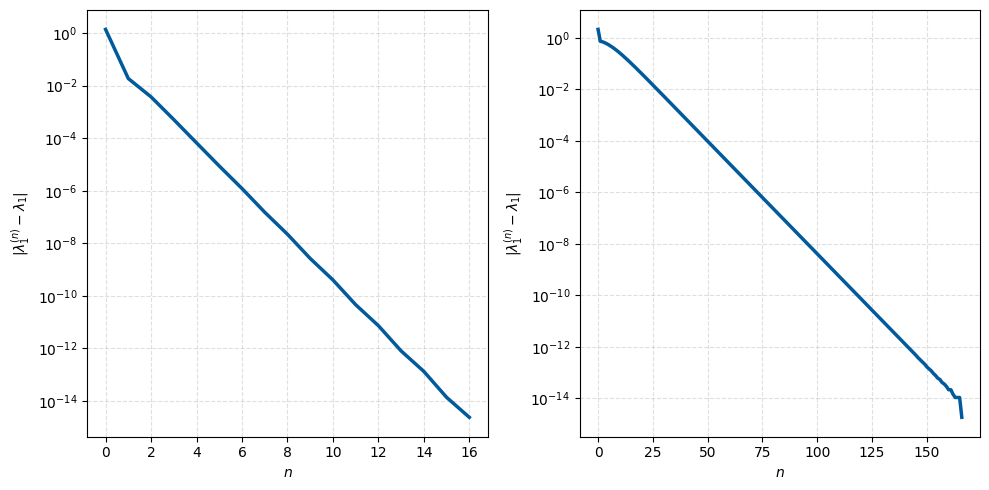

In [147]:

A_real = np.random.rand(3,3)
A_compl = np.array([
    [4,   -1j,        2],
    [1j,   2,   2 + 7j],
    [2,  2 - 7j,     -2]
], dtype=complex)

def plot_convergence(A_in):
    N_max = 100000
    epsilon = 1e-14
    A = np.copy(A_in)
    
    errors = []
    x_0 = np.random.rand(len(A)) + 1j*np.random.rand(len(A))
    y = x_0 / np.sqrt(np.real(x_0.T.conj() @ x_0))      # choice of a random vector
    
    lamb_old = 0.0

    for i in range(N_max):
        y = A @ y                       
        y = y / np.sqrt(np.real(y.T.conj() @ y))    # the vector is chosen normalised
        
        # Rayleigh Quotient
        lamb_new = y.T.conj() @ A @ y    # y is normalised --> lamb1 is the next eigval
        
        # error respect to the previous step
        err = abs(lamb_new - lamb_old)
        errors.append(err)
        
        if err < epsilon:
            print(f'Iteration {i}: reached max precision\n')
            break
        
        lamb_old = lamb_new

    return np.array([np.arange(len(errors)), errors])




out_real = plot_convergence(A_real)
out_comp = plot_convergence(A_compl)

# Plot
fig, ax = plt.subplots(1, 2, figsize=(10, 5))
# plt.title(r'Convergenza di \textbf{Power Method}')

ax[0].plot(out_real[0], out_real[1], color='#005a9c', linewidth=2.5)
ax[0].set_yscale('log')
ax[0].set_xlabel(r'$n$')
ax[0].set_ylabel(r'$|\lambda_1^{(n)} - \lambda_1|$')
ax[0].grid(alpha=0.4, ls='--')

ax[1].plot(out_comp[0], out_comp[1], color='#005a9c', linewidth=2.5)
ax[1].set_yscale('log')
ax[1].set_xlabel(r'$n$')
ax[1].set_ylabel(r'$|\lambda_1^{(n)} - \lambda_1|$')
ax[1].grid(alpha=0.4, ls='--')
plt.tight_layout()
plt.show()



## **Matrice complessa**

In [148]:
A_test = np.array([
    [4,   -1j,        2],
    [1j,   2,   2 + 7j],
    [2,  2 - 7j,     -2]
], dtype=complex)

eig_val, eig_vect = power_mth(A_test)
print('A =', A_test)
print()
print('MAX eig_val =', eig_val)
print('eig_vect =', eig_vect)


A = [[ 4.+0.j -0.-1.j  2.+0.j]
 [ 0.+1.j  2.+0.j  2.+7.j]
 [ 2.+0.j  2.-7.j -2.+0.j]]

MAX eig_val = (8.451876899596726-3.1086244689504383e-15j)
eig_vect = [0.63491092-0.59342626j 1.18122253+0.91110263j 0.95772132-0.73031907j]


## **Inverse Power Method**
calculate the smallest eigenvalue with the inverse power method using the QR solver developed in previous exercises

In [149]:
def inv_power_mth(A_in, epsilon=1e-14, N_max=10000):
    A = np.copy(A_in)
    x_k = np.random.rand(len(A))    # choice of a random vector
    x_k = x_k / np.sqrt(x_k@x_k)      # the vector is chosen normalised
    lambold = 1
    lambnew = 0
    Q, R = QR_dec(A)
    # x_k+1 = A^-1 x --> A x_k+1 = x --> Q R x_k+1 = x --> 
    # --> R x_k+1 = Q^-1 x = Q.T x = d 
    # R x_k+1 = d 

    for i in range(N_max):
        if np.abs(lambold - lambnew) > epsilon:
            d = Q.conj().T @ x_k
            x_k1 = back_subst(R, d)
            num = x_k.conj().T @ x_k
            den = x_k.conj().T @ x_k1
            x_k1 = x_k1 / np.sqrt(x_k1@x_k1)
            x_k = x_k1

            lambold = lambnew
            # Rayleigh Factor
            lambnew = num / den 
        else:
            print(f'Iteration {i}: reached max precision (inv pwr mth)')
            break
        
    eigVal = lambold 
    eigVect = x_k
    if np.sum(A @ eigVect) - np.sum(eigVal * eigVect) > 1e-8:
        raise ValueError('Eigenvalue/vector is not accurate')

    return eigVal, eigVect

print('A =', A_test)

print()
eig_val, eig_vect = power_mth(A_test)
print('MAX eig_val =', eig_val)
print('eig_vect =', eig_vect)

print()
eig_val, eig_vect = inv_power_mth(A_test)
diff = A_test@eig_vect - eig_val*eig_vect
print('min eig_val =', eig_val)
print('eig_vect =', eig_vect)


print()
eigval, eigvect = QR_eigensolver(A_test)
print('Lambdas =', eigval)
print('Vects =\n', eigvect)


A = [[ 4.+0.j -0.-1.j  2.+0.j]
 [ 0.+1.j  2.+0.j  2.+7.j]
 [ 2.+0.j  2.-7.j -2.+0.j]]

Iteration 360: reached max precision (pwr mth)
MAX eig_val = (8.451876899596733+0j)
eig_vect = [0.63491092-0.59342626j 1.18122253+0.91110263j 0.95772132-0.73031907j]

Iteration 22: reached max precision (inv pwr mth)
min eig_val = (3.1896027470480606-1.886224989740341e-16j)
eig_vect = [ 1.0635115 -0.05265637j -0.11242583-0.43133197j -0.21526741-0.03487663j]

Tolerance reached at step 203 (QR eigen)
Lambdas = [ 8.4518769 -2.37823613e-16j -7.64147965+6.82884752e-16j
  3.18960275+1.72542130e-17j]
Vects =
 [[ 0.41284464+1.93934760e-17j -0.03061002+8.39647584e-02j
   0.90626703-1.58842009e-02j]
 [ 0.11440717+6.99367493e-01j -0.59205186+5.74658084e-02j
  -0.08392438-3.70033888e-01j]
 [ 0.56928302+5.72035837e-02j  0.14944007-7.84762946e-01j
  -0.18220121-3.55259355e-02j]]
